In [5]:
import os
print(os.environ.get("ANTHROPIC_API_KEY", "NOT SET")[:20])

sk-ant-api03-I2c5R2j


In [6]:
"""Demo: automated cell type annotation with celltype-agent.

Run this as a plain Python script, or convert to a Jupyter notebook with:

    pip install jupytext
    jupytext --to notebook notebooks/demo.py

Each "# %%" marker is a notebook cell boundary when opened with Jupytext or
the VS Code Jupyter extension.
"""

'Demo: automated cell type annotation with celltype-agent.\n\nRun this as a plain Python script, or convert to a Jupyter notebook with:\n\n    pip install jupytext\n    jupytext --to notebook notebooks/demo.py\n\nEach "# %%" marker is a notebook cell boundary when opened with Jupytext or\nthe VS Code Jupyter extension.\n'

# celltype-agent demo

Automated cell type annotation for single-cell RNA-seq data using Claude.

**Prerequisites**
```bash
pip install celltype-agent[scanpy]
export ANTHROPIC_API_KEY=sk-ant-...
```

## 1. Load PBMC3K

In [7]:
import warnings

warnings.filterwarnings("ignore")

import scanpy as sc

sc.settings.verbosity = 1

# Download and preprocess the classic 3k PBMC dataset.
# scanpy caches it locally so subsequent runs are instant.
adata = sc.datasets.pbmc3k_processed()
print(adata)

  0%|          | 0.00/23.5M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


## 2. Annotate clusters

In [8]:
import logging

# Basic logging so progress messages appear in the notebook output
logging.basicConfig(level=logging.INFO, format="%(message)s")

from celltype_agent import annotate

messages = []

result = annotate(
    adata,
    species="human",
    tissue="PBMC",
    cluster_key="louvain",     # PBMC3K uses louvain clusters
    n_markers=10,
    progress_callback=messages.append,
)

Extracting top 10 markers per cluster (key='louvain') …
Using cached rank_genes_groups (groupby='louvain')
Found 8 clusters. Sending to claude-opus-4-6 for annotation …
Sending 8 clusters to claude-opus-4-6 for annotation…
HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
Loading PanglaoDB from /home/phil/projects/celltype-agent/data/PanglaoDB_markers_27_Mar_2020.tsv …
PanglaoDB loaded: 8286 rows.
Loading CellMarker from /home/phil/projects/celltype-agent/data/Cell_marker_All.xlsx …
CellMarker loaded: 59492 rows.
HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
All 8 clusters annotated in 3 turn(s).
Annotation complete — 8 cluster(s) annotated.
Wrote cell type labels to adata.obs['cell_type'].


## 3. Rich HTML summary (auto-rendered in Jupyter)

In [9]:
result   # triggers _repr_html_ in Jupyter; prints repr in script mode

Cluster,Cell Type,Confidence,Key Markers,DB Support
0,Naïve CD4+ T cell,0.88,"CD3D, CD3E, LTB, LDHB","4/10 matched — 4/10 markers (CD3D, CD3E, LTB, LDHB) were confirmed in PanglaoDB and/or CellMarker CD4+ T cell lists. The remaining markers are ribosomal housekeeping genes not expected in curated marker databases. Both databases list CD3D, CD3E, and LTB as CD4+ T cell markers, supporting this annotation."
1,CD14+ Monocyte,0.95,"LYZ, S100A9, S100A8, FCN1, TYROBP","5/10 matched — Direct cell-type search confirmed LYZ and S100A9 (2/10). Gene-based searches for FCN1, S100A8, and TYROBP all returned Monocytes/Classical monocytes as top hits in both PanglaoDB and CellMarker, bringing effective confirmation to 5/10 markers. Databases strongly agree this is a monocyte cluster."
2,B cell,0.98,"CD79A, CD79B, MS4A1, CD74, HLA-DRA","10/10 matched — 10/10 markers were confirmed in PanglaoDB and/or CellMarker B cell lists. CD79A, CD79B, MS4A1, CD74, HLA-DRA, HLA-DQA1, HLA-DPB1, HLA-DQB1, HLA-DRB1, and HLA-DPA1 are all present. This is a textbook-perfect match."
3,CD8+ T cell,0.95,"CD8A, CD3D, CCL5, NKG7, GZMA","9/10 matched — 9/10 markers (CCL5, NKG7, CST7, GZMA, GZMK, CTSW, IL32, CD8A, CD3D) were confirmed in PanglaoDB and/or CellMarker CD8+ T cell lists. Only LYAR was absent. Both databases strongly support CD8+ T cell identity."
4,NK cell,0.95,"NKG7, GNLY, PRF1, GZMB, FGFBP2","9/10 matched — 9/10 markers (NKG7, GZMB, GNLY, PRF1, FGFBP2, CTSW, CST7, GZMA, SPON2) were confirmed in PanglaoDB NK cell marker lists. Only CD247 was not in the NK-specific list (though it is a known NK/T cell gene). Databases strongly support NK cell identity."
5,CD16+ (non-classical) Monocyte,0.90,"FCGR3A, LST1, AIF1, FCER1G, IFITM2","4/10 matched — Direct cell-type search for CD16+ monocytes confirmed FCGR3A (1/10). Gene searches for LST1, AIF1, and FCER1G all returned monocytes as a top associated cell type, bringing total support to 4/10. The limited database entries for CD16+ monocytes are a known gap; the marker profile is highly consistent with published scRNA-seq annotations of FCGR3A+ monocytes."
6,Dendritic cell,0.90,"HLA-DRA, HLA-DPB1, HLA-DPA1, CST3, CD74","9/10 matched — 9/10 markers (HLA-DPB1, HLA-DPA1, HLA-DRA, CST3, CD74, HLA-DRB1, HLA-DQA1, HLA-DMA, HLA-DRB5) were confirmed in PanglaoDB and/or CellMarker dendritic cell lists. Only LSP1 was absent. Databases strongly support dendritic cell identity."
7,Platelet,0.98,"PPBP, PF4, GP9, GNG11, SPARC","8/10 matched — 8/10 markers (PPBP, PF4, GPX1, GNG11, SPARC, CD9, NRGN, GP9) were confirmed in PanglaoDB and/or CellMarker platelet lists. SDPR (CAVIN2) is also listed in PanglaoDB under its newer symbol. Only CALM3 was absent. Databases strongly confirm platelet identity."


## 4. Annotations as a DataFrame

In [10]:
df = result.to_dataframe()
df

,cluster_id,predicted_type,confidence,markers_used,reasoning,database_support,database_markers_matched,database_markers_total
0,0,Naïve CD4+ T cell,0.88,"CD3D, CD3E, LTB, LDHB",CD3D and CD3E are canonical T cell receptor co...,"4/10 markers (CD3D, CD3E, LTB, LDHB) were conf...",4,10
1,1,CD14+ Monocyte,0.95,"LYZ, S100A9, S100A8, FCN1, TYROBP, CST3","LYZ, S100A9, and S100A8 are textbook CD14+ mon...",Direct cell-type search confirmed LYZ and S100...,5,10
2,2,B cell,0.98,"CD79A, CD79B, MS4A1, CD74, HLA-DRA, HLA-DQA1",CD79A and CD79B are components of the B cell r...,10/10 markers were confirmed in PanglaoDB and/...,10,10
3,3,CD8+ T cell,0.95,"CD8A, CD3D, CCL5, NKG7, GZMA, GZMK",CD8A combined with CD3D unambiguously identifi...,"9/10 markers (CCL5, NKG7, CST7, GZMA, GZMK, CT...",9,10
4,4,NK cell,0.95,"NKG7, GNLY, PRF1, GZMB, FGFBP2, SPON2","NKG7, GNLY (granulysin), PRF1 (perforin), and ...","9/10 markers (NKG7, GZMB, GNLY, PRF1, FGFBP2, ...",9,10
5,5,CD16+ (non-classical) Monocyte,0.90,"FCGR3A, LST1, AIF1, FCER1G, IFITM2, IFITM3",FCGR3A (CD16) is the defining marker of non-cl...,Direct cell-type search for CD16+ monocytes co...,4,10
6,6,Dendritic cell,0.90,"HLA-DRA, HLA-DPB1, HLA-DPA1, CST3, CD74, HLA-DMA",This cluster shows extremely high MHC class II...,"9/10 markers (HLA-DPB1, HLA-DPA1, HLA-DRA, CST...",9,10
7,7,Platelet,0.98,"PPBP, PF4, GP9, GNG11, SPARC, NRGN",PPBP (pro-platelet basic protein/CXCL7) and PF...,"8/10 markers (PPBP, PF4, GPX1, GNG11, SPARC, C...",8,10


## 5. Save to CSV

In [11]:
result.to_csv("pbmc3k_annotations.csv")
print("Saved to pbmc3k_annotations.csv")

Saved to pbmc3k_annotations.csv


## 6. Inspect the annotated AnnData

In [12]:
# annotate() wrote labels back to adata.obs["cell_type"] by default
print(adata.obs[["louvain", "cell_type"]].drop_duplicates().sort_values("louvain"))

                            louvain cell_type
index                                        
AAACATACAACCAC-1        CD4 T cells       NaN
AAACCGTGCTTCCG-1    CD14+ Monocytes       NaN
AAACATTGAGCTAC-1            B cells       NaN
AAACGCACTGGTAC-1        CD8 T cells       NaN
AAACCGTGTATGCG-1           NK cells       NaN
AAACGCTGTTTCTG-1  FCGR3A+ Monocytes       NaN
AAGATTACCGCCTT-1    Dendritic cells       NaN
ACCCACTGGTTCAG-1     Megakaryocytes       NaN


## 7. UMAP coloured by predicted cell type

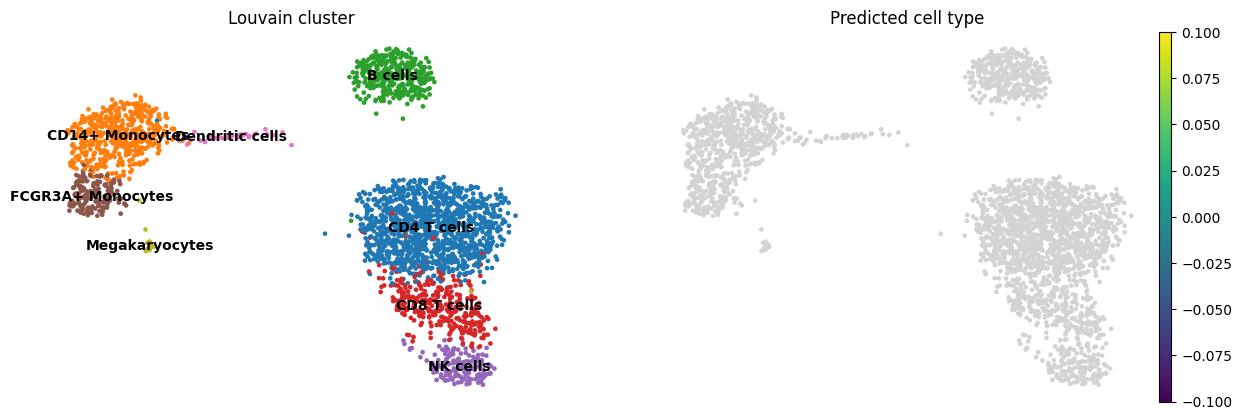

In [13]:
sc.pl.umap(
    adata,
    color=["louvain", "cell_type"],
    legend_loc="on data",
    frameon=False,
    title=["Louvain cluster", "Predicted cell type"],
)